<a href="https://colab.research.google.com/github/OJB-Quantum/Qiskit-Metal-to-Litho/blob/main/Single_CPW_Resonator_with_Quantum_Metal_GDSTK_PHIDL_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
"""This script configures the environment for headless operation, installs
scientific dependencies, and patches Quantum Metal to remove Graphical User Interface
dependencies while preserving the Graphic Database System toolchain required for layouts.

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)
"""

import logging
import os
import re
import sys
import textwrap
from pathlib import Path

os.environ["QT_QPA_PLATFORM"] = "offscreen"
os.environ["MPLBACKEND"] = "Agg"

import matplotlib as mpl
try:
    mpl.use("Agg", force=True)
except TypeError:
    mpl.use("Agg")

REPO_URL = "https://github.com/qiskit-community/qiskit-metal"
ROOT_DIR = Path("/content/qiskit-metal")
SRC_DIR = ROOT_DIR / "src"
PKG_DIR = SRC_DIR / "qiskit_metal"

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


def install_dependencies():
    """Installs required scientific and Graphic Database System toolchain."""
    logger.info("Installing dependencies...")
    os.system("pip install uv")
    !uv pip install --system --upgrade pip wheel

    packages = [
        "numpy>=1.24", "matplotlib>=3.8", "gdstk>=0.9.61",
        "shapely>=2.0", "ezdxf>=1.2.0", "pandas>=2.0",
        "scipy>=1.10", "networkx>=2.8", "pint>=0.20",
        "addict>=2.4.0", "pyyaml>=6.0.1", "qutip>=4.7",
        "h5py>=3.8", "descartes>=1.1", "jedi>=0.19.1"
    ]
    packages_str = " ".join(packages)
    !uv pip install --system {packages_str}
    logger.info("Dependencies installed successfully.")


def setup_repository():
    """Clones the Qiskit Metal repository to obtain the latest version."""
    logger.info("Cleaning old installation and cloning repository...")
    !rm -rf {ROOT_DIR}
    !git clone -b main {REPO_URL} {ROOT_DIR}

    if not PKG_DIR.exists():
        raise RuntimeError(f"Git clone failed to provide package folder at {PKG_DIR}.")

    return PKG_DIR


def configure_python_path():
    """Configures sys.path and PYTHONPATH."""
    if str(SRC_DIR) not in sys.path:
        sys.path.insert(0, str(SRC_DIR))

    current_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = f"{SRC_DIR}:{current_pythonpath}"
    logger.info("Python path configured to include %s", SRC_DIR)


def patch_package_init():
    """Replaces the package __init__.py with a headless version."""
    init_file = PKG_DIR / "__init__.py"
    if not init_file.exists():
        return

    orig_init = init_file.read_text(encoding="utf-8")
    (PKG_DIR / "__init__orig.py").write_text(orig_init, encoding="utf-8")

    minimal_init = textwrap.dedent("""
        import logging as _logging

        __version__ = "0.8.1"

        try:
            from addict import Dict as Dict
        except Exception:
            try:
                from .toolbox_python.attr_dict import Dict
            except Exception:
                class Dict(dict): pass

        logger = _logging.getLogger("qiskit_metal_colab")

        class _Config:
            renderers_to_load = {
                'gds': {'path_name': 'qiskit_metal.renderers.gds.GdsRenderer'},
            }
            @staticmethod
            def is_building_docs():
                return False
        config = _Config()

        def is_design(obj):
            try:
                from .designs.design_base import QDesign
                return isinstance(obj, QDesign)
            except Exception:
                return False

        def is_component(obj):
            try:
                from .qlibrary.core.base import QComponent
                return isinstance(obj, QComponent)
            except Exception:
                return False

        __all__ = ["Dict", "config", "logger", "is_design", "is_component", "__version__"]
    """).strip() + "\n"

    init_file.write_text(minimal_init, encoding="utf-8")
    logger.info("Patched %s for headless mode with Graphic Database System support.", init_file)


def scrub_draw_imports():
    """Removes GUI Toolkit dependencies from the draw module initialization."""
    draw_init = PKG_DIR / "draw" / "__init__.py"
    if not draw_init.exists():
        return

    content = draw_init.read_text(encoding="utf-8")

    content = re.sub(
        r'^\s*from\s+\.\s*import\s+mpl\s*$',
        "try:\n    from . import mpl\n"
        "except Exception as _e:\n"
        "    print('[colab] draw.mpl disabled (headless):', _e)\n",
        content,
        flags=re.MULTILINE,
    )

    content = re.sub(
        r'^\s*from\s+\.\s*mpl\s+import[^\n]*$',
        "try:\n    from .mpl import render, figure_spawn\n"
        "except Exception as _e:\n"
        "    print('[colab] draw.mpl (named) disabled (headless):', _e)\n"
        "    def render(*a, **k):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n"
        "    def figure_spawn(*a, **k):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n",
        content,
        flags=re.MULTILINE,
    )

    draw_init.write_text(content, encoding="utf-8")
    logger.info("Scrubbed GUI Toolkit imports from %s", draw_init)


def main():
    """Executes the primary workflow for Qiskit Metal setup."""
    try:
        install_dependencies()
        setup_repository()
        configure_python_path()
        patch_package_init()
        scrub_draw_imports()
    except Exception as e:
        logger.error("Setup failed: %s", e)
        raise

if __name__ == "__main__":
    main()

Quantum Metal runtime version: 0.8.1
Documentation target:          0.8.1

Components: ['LP_IN', 'LP_OUT', 'HANGER_COUPLER', 'FEED_LEFT', 'FEED_RIGHT', 'RESONATOR_SHORT', 'HANGER_RESONATOR']
Renderers: ['gds']
Feedline-to-furthest resonator tip: 3000.0 um
QGeometry tables: ['path', 'poly', 'junction']
  path: 10 row(s)
  poly: 4 row(s)
  junction: 0 row(s)

Design rules passed (7 rules ran, no findings).

DRC gate passed with zero errors and zero warnings.

OASIS written to: /content/hanger_mode_cpw_resonator.oas
OASIS file size: 20.1 KiB
OASIS top-level cells: 1


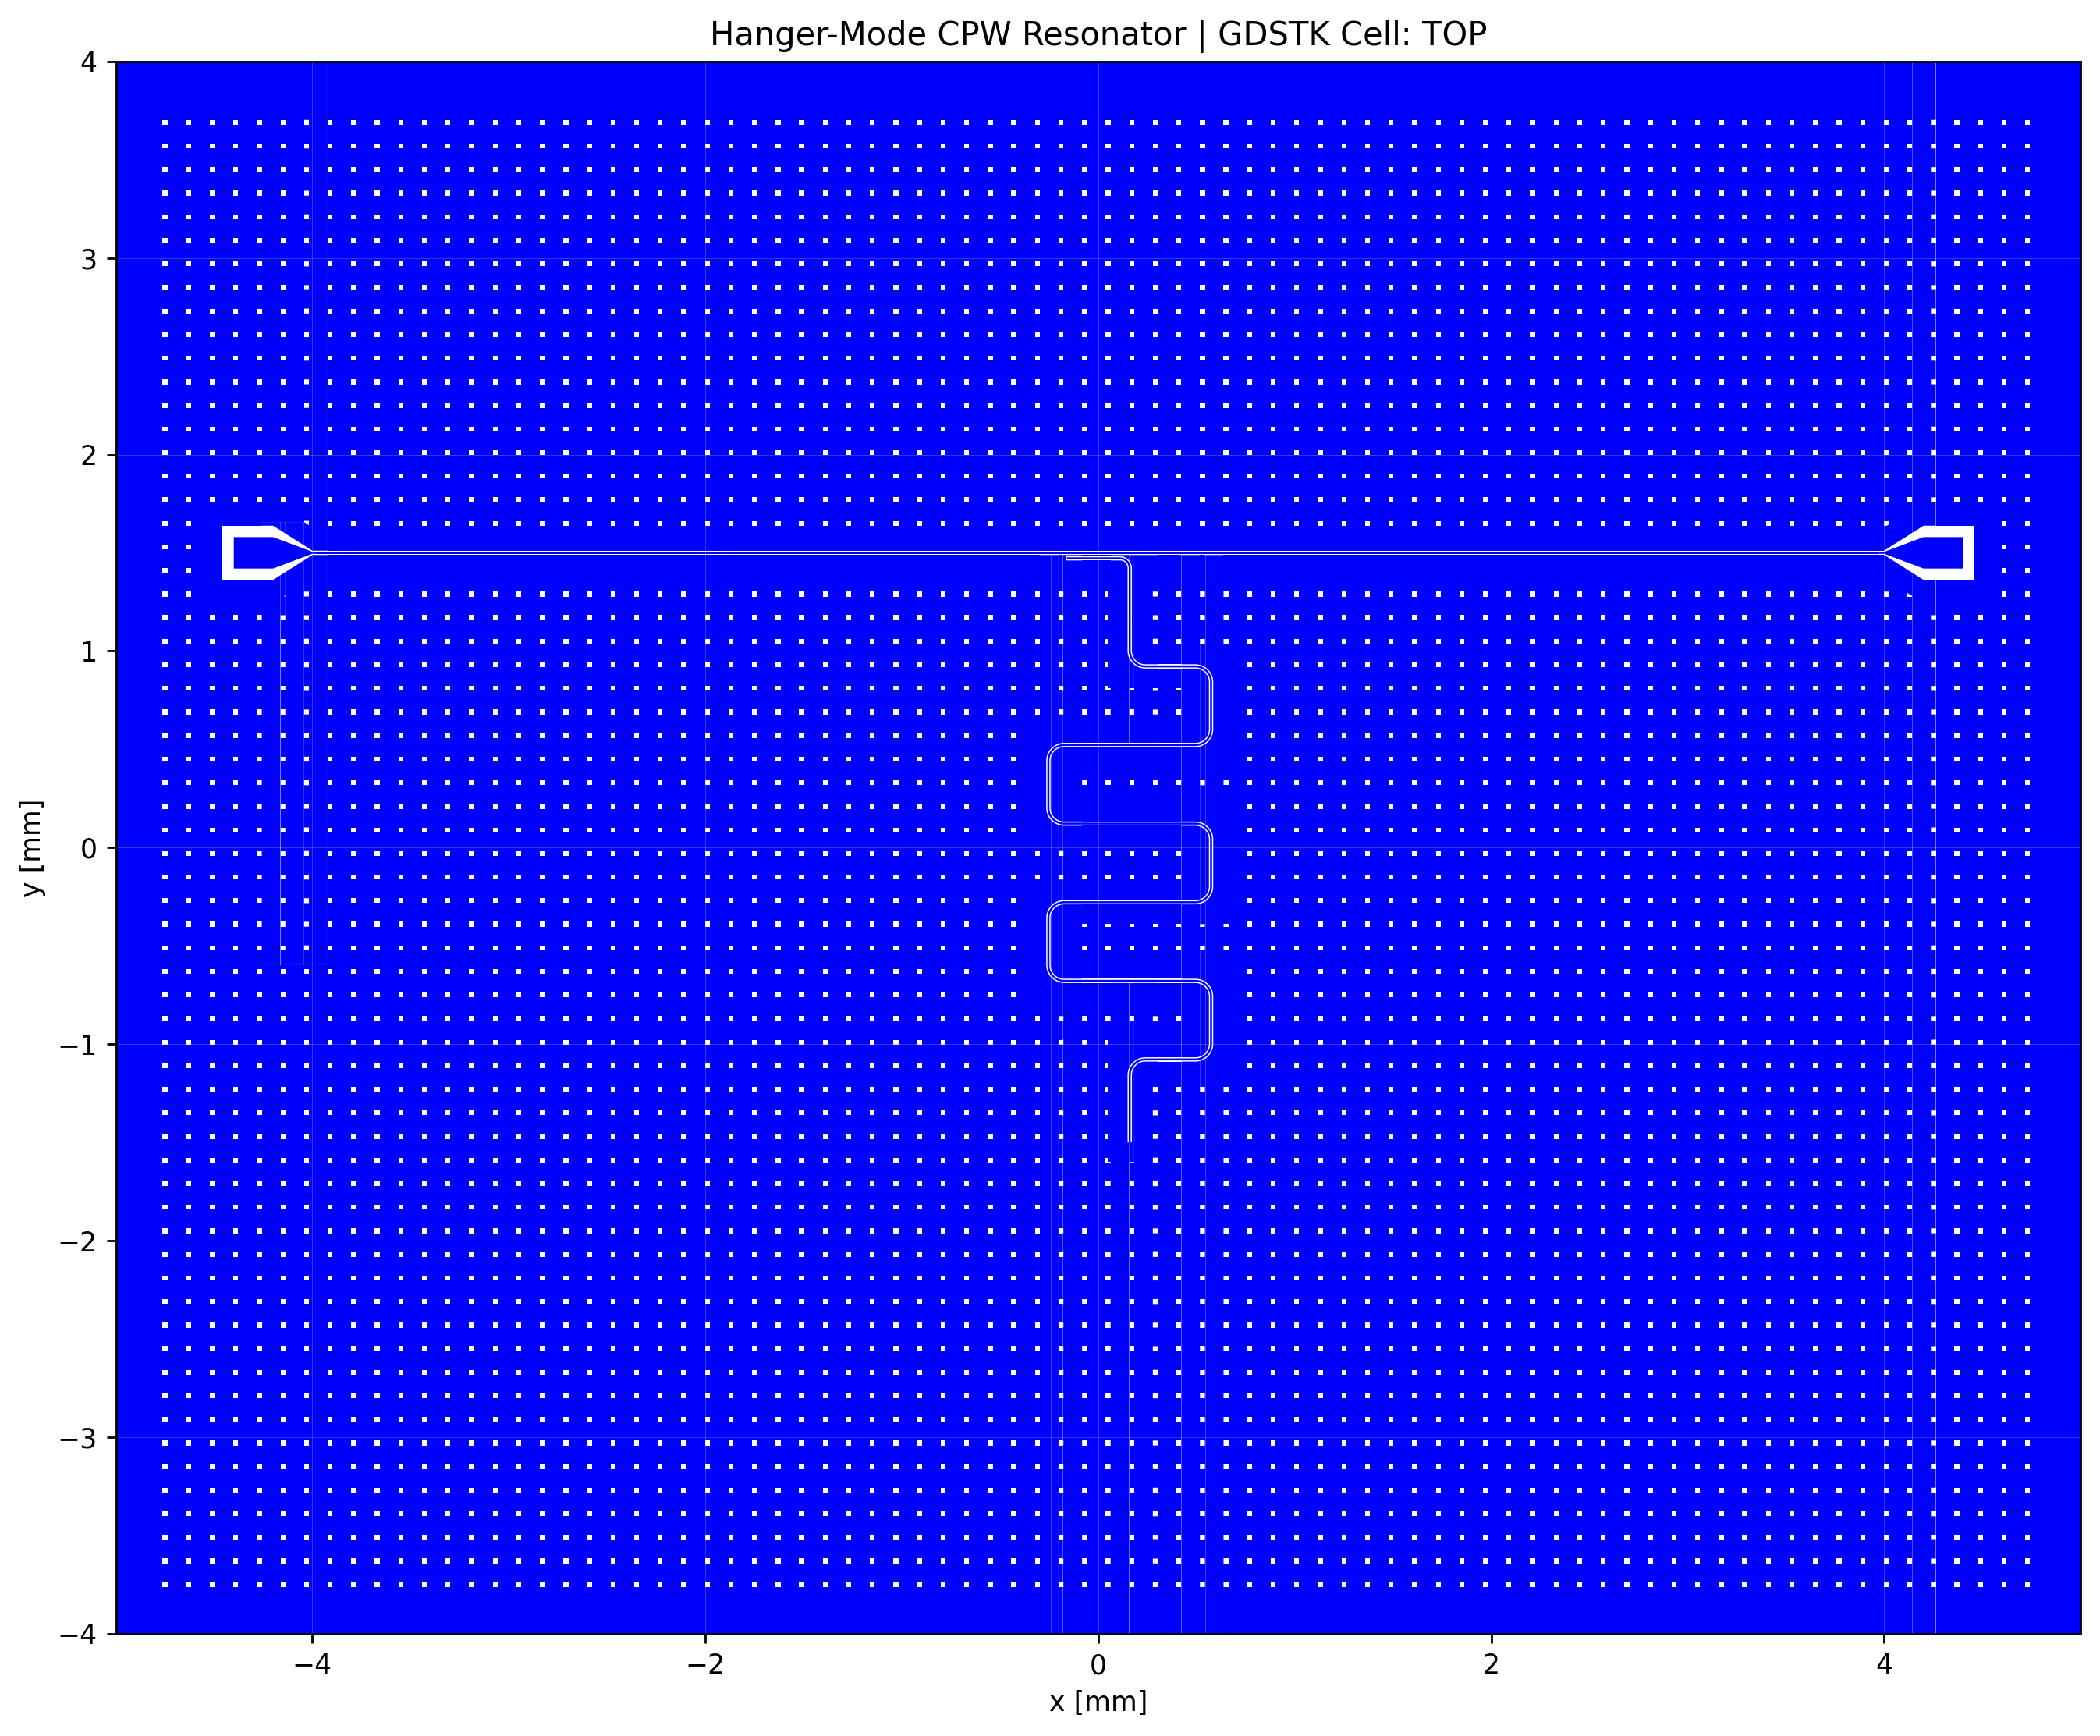

In [ ]:
"""Build a DRC-gated hanger-mode CPW resonator with Quantum Metal.

This script creates a headless planar microwave layout containing two
wirebond launchers, a CPW feedline, a CoupledLineTee, and a quarter-wave
hanger resonator terminated with ShortToGround.

Quantum Metal's built-in design-rule checker evaluates the completed
layout before fabrication geometry is generated. The layout is rendered
with the GDS renderer, including ground-plane generation, cheesing, and
no-cheese keepout processing. Its in-memory GDSTK library is previewed
with Matplotlib and exported directly to OASIS with GDSTK.
"""

import os
import warnings
from pathlib import Path
from typing import Final

os.environ.setdefault("MPLBACKEND", "Agg")

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.collections import PolyCollection

import qiskit_metal as qm
from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.couplers.coupled_line_tee import (
    CoupledLineTee,
)
from qiskit_metal.qlibrary.terminations.launchpad_wb import (
    LaunchpadWirebond,
)
from qiskit_metal.qlibrary.terminations.short_to_ground import (
    ShortToGround,
)
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.renderers.renderer_gds.gds_renderer import (
    QGDSRenderer,
)
from qiskit_metal.validation import validate


class CPWGDSRenderer(QGDSRenderer):
    """Render CPW layouts with junction-aware GDS handling."""

    def _import_junctions_to_one_cell(
        self,
        chip_name: str,
        lib: gdstk.Library,
        chip_only_top: gdstk.Cell,
        layers_in_chip: list,
    ) -> None:
        """Import junction cells only for chips containing junction geometry.

        Args:
            chip_name: Name of the chip being rendered.
            lib: GDSTK library receiving the rendered hierarchy.
            chip_only_top: Top-level cell for the selected chip.
            layers_in_chip: Layers present on the selected chip.
        """
        junction_table = self.chip_info[chip_name].get("junction")

        if junction_table is None or junction_table.empty:
            return

        super()._import_junctions_to_one_cell(
            chip_name,
            lib,
            chip_only_top,
            layers_in_chip,
        )


# -----------------------------------------------------------------------------
# Control knobs - API and execution
# -----------------------------------------------------------------------------

DOCUMENTED_QMETAL_VERSION: Final[str] = "0.8.1"
ENFORCE_DOCUMENTED_VERSION: Final[bool] = True

PLOT_DPI: Final[int] = 250
PLOT_LAYER_COLOR: Final[str] = "#0000FF"

OUTPUT_DIRECTORY: Final[Path] = Path("/content")
OUTPUT_OAS_FILENAME: Final[str] = "hanger_mode_cpw_resonator.oas"
INTERMEDIATE_GDS_FILENAME: Final[str] = "_qmetal_hanger.gds"

OASIS_COMPRESSION_LEVEL: Final[int] = 9

DRC_WARNINGS_BLOCK_EXPORT: Final[bool] = False
SHOW_QMETAL_PANDAS_FUTURE_WARNINGS: Final[bool] = False

# -----------------------------------------------------------------------------
# Control knobs - coordinate grid
# -----------------------------------------------------------------------------

GRID_SNAPPING_ENABLED: Final[bool] = True
GRID_PITCH_UM: Final[float] = 1.0

MEANDER_SHORT_EDGE_PROTECTION: Final[bool] = True

# -----------------------------------------------------------------------------
# Control knobs - chip
# -----------------------------------------------------------------------------

CHIP_WIDTH_MM: Final[float] = 10.0
CHIP_HEIGHT_MM: Final[float] = 8.0

METAL_LAYER: Final[int] = 1

# -----------------------------------------------------------------------------
# Control knobs - common CPW
# -----------------------------------------------------------------------------

CPW_WIDTH_UM: Final[float] = 10.0
CPW_GAP_UM: Final[float] = 6.0

FEEDLINE_Y_MM: Final[float] = 1.50

# -----------------------------------------------------------------------------
# Control knobs - launchers
# -----------------------------------------------------------------------------

LAUNCHER_X_MM: Final[float] = 4.00

LAUNCH_PAD_WIDTH_UM: Final[float] = 160.0
LAUNCH_PAD_HEIGHT_UM: Final[float] = 200.0
LAUNCH_PAD_GAP_UM: Final[float] = 58.0
LAUNCH_TAPER_HEIGHT_UM: Final[float] = 200.0
LAUNCH_LEAD_LENGTH_UM: Final[float] = 25.0

# -----------------------------------------------------------------------------
# Control knobs - hanger coupler
# -----------------------------------------------------------------------------

COUPLING_LENGTH_UM: Final[float] = 320.0
COUPLING_SPACE_UM: Final[float] = 6.0

COUPLER_DOWN_LENGTH_UM: Final[float] = 300.0
COUPLER_FILLET_UM: Final[float] = 50.0

COUPLER_MIRRORED: Final[bool] = False


# -----------------------------------------------------------------------------
# Control knobs - quarter-wave resonator
# -----------------------------------------------------------------------------

RESONATOR_ROUTE_LENGTH_MM: Final[float] = 6.40

RESONATOR_MEANDER_SPACING_UM: Final[float] = 400.0
RESONATOR_MEANDER_ASYMMETRY_UM: Final[float] = 0.0

RESONATOR_FILLET_UM: Final[float] = 80.0
RESONATOR_START_STRAIGHT_UM: Final[float] = 250.0
RESONATOR_END_STRAIGHT_UM: Final[float] = 250.0

# Default: 3000 um from the feedline centerline to the furthest resonator tip.
RESONATOR_FURTHEST_TIP_DISTANCE_UM: Final[float] = 3000.0


# -----------------------------------------------------------------------------
# Control knobs - cheesing
# -----------------------------------------------------------------------------

CHEESING_ENABLED: Final[bool] = True
CHEESE_AVOIDANCE_ENABLED: Final[bool] = True

CHEESE_HOLE_WIDTH_UM: Final[float] = 25.0
CHEESE_HOLE_HEIGHT_UM: Final[float] = 25.0

CHEESE_PITCH_X_UM: Final[float] = 120.0
CHEESE_PITCH_Y_UM: Final[float] = 120.0

CHEESE_EDGE_KEEPOUT_UM: Final[float] = 250.0
CHEESE_COMPONENT_KEEPOUT_UM: Final[float] = 100.0

CHEESE_DATATYPE: Final[int] = 100
NO_CHEESE_DATATYPE: Final[int] = 99


# -----------------------------------------------------------------------------
# Matplotlib configuration
# -----------------------------------------------------------------------------

mpl.rcParams.update(
    {
        "figure.dpi": PLOT_DPI,
        "savefig.dpi": PLOT_DPI,
        "font.sans-serif": ["Tahoma", "DejaVu Sans"],
        "font.weight": "normal",
    }
)


# -----------------------------------------------------------------------------
# Unit and snapping helpers
# -----------------------------------------------------------------------------

def _snap_um(value_um: float) -> float:
    """Snap a coordinate or dimension to the fabrication grid.

    Args:
        value_um: Value expressed in micrometres.

    Returns:
        Grid-quantized value in micrometres.

    Raises:
        ValueError: If the grid pitch is zero or negative.
    """
    if GRID_PITCH_UM <= 0.0:
        raise ValueError(
            "GRID_PITCH_UM must be greater than zero."
        )

    if not GRID_SNAPPING_ENABLED:
        return value_um

    grid_index = round(value_um / GRID_PITCH_UM)

    return grid_index * GRID_PITCH_UM


def _um(value_um: float) -> str:
    """Convert micrometres to a Quantum Metal dimensional string.

    Args:
        value_um: Value expressed in micrometres.

    Returns:
        Quantum Metal dimensional string.
    """
    value = _snap_um(value_um)

    if abs(value) < 1.0e-15:
        value = 0.0

    return f"{value:.12g}um"


def _mm(value_mm: float) -> str:
    """Convert millimetres to a Quantum Metal dimensional string.

    Args:
        value_mm: Value expressed in millimetres.

    Returns:
        Quantum Metal dimensional string.
    """
    return _um(value_mm * 1000.0)


def _bool_string(value: bool) -> str:
    """Convert a Boolean to Quantum Metal's lowercase string form.

    Args:
        value: Boolean setting.

    Returns:
        ``"true"`` or ``"false"``.
    """
    return "true" if value else "false"


# -----------------------------------------------------------------------------
# Runtime checks
# -----------------------------------------------------------------------------

def configure_warning_filters() -> None:
    """Configure warning visibility for the Quantum Metal runtime."""
    if SHOW_QMETAL_PANDAS_FUTURE_WARNINGS:
        return

    warning_message = (
        r"The behavior of DataFrame concatenation with empty or all-NA "
        r"entries is deprecated\..*"
    )

    warning_modules = (
        r"qiskit_metal\.qgeometries\.qgeometries_handler",
        r"qiskit_metal\.renderers\.renderer_gds\.gds_renderer",
    )

    for module_pattern in warning_modules:
        warnings.filterwarnings(
            "ignore",
            message=warning_message,
            category=FutureWarning,
            module=module_pattern,
        )


def check_qmetal_version() -> None:
    """Verify the Quantum Metal runtime version.

    Raises:
        RuntimeError: If runtime version enforcement is active and the
            installed version differs from the configured version.
    """
    installed_version = str(
        getattr(qm, "__version__", "unknown")
    ).split("+", maxsplit=1)[0]

    print(
        f"Quantum Metal runtime version: {installed_version}"
    )
    print(
        f"Documentation target:          "
        f"{DOCUMENTED_QMETAL_VERSION}"
    )

    if (
        ENFORCE_DOCUMENTED_VERSION
        and installed_version != DOCUMENTED_QMETAL_VERSION
    ):
        raise RuntimeError(
            "Installed Quantum Metal version differs from "
            "DOCUMENTED_QMETAL_VERSION."
        )


def _create_planar_design():
    """Create a planar design with a directly registered GDS renderer.

    Returns:
        Tuple containing the design and its GDS renderer.
    """
    CPWGDSRenderer.load()

    design = designs.DesignPlanar(
        overwrite_enabled=True,
        enable_renderers=False,
    )

    gds_renderer = CPWGDSRenderer(
        design=design,
        initiate=False,
    )

    gds_renderer.add_table_data_to_QDesign(
        gds_renderer.name
    )

    design.renderers["gds"] = gds_renderer

    if "gds" not in design.renderers:
        raise RuntimeError(
            "QGDSRenderer registration failed."
        )

    if design.renderers["gds"] is not gds_renderer:
        raise RuntimeError(
            "QGDSRenderer registration is inconsistent."
        )

    return design, gds_renderer


# -----------------------------------------------------------------------------
# Layout construction
# -----------------------------------------------------------------------------

def build_design():
    """Create the CPW feedline and quarter-wave hanger resonator.

    Returns:
        Fully rebuilt Quantum Metal DesignPlanar instance.
    """
    design, _ = _create_planar_design()

    design.chips.main.size.size_x = _mm(
        CHIP_WIDTH_MM
    )
    design.chips.main.size.size_y = _mm(
        CHIP_HEIGHT_MM
    )

    design.variables["cpw_width"] = _um(
        CPW_WIDTH_UM
    )
    design.variables["cpw_gap"] = _um(
        CPW_GAP_UM
    )

    LaunchpadWirebond(
        design,
        "LP_IN",
        options=Dict(
            pos_x=_mm(-LAUNCHER_X_MM),
            pos_y=_mm(FEEDLINE_Y_MM),
            orientation="0",
            layer=str(METAL_LAYER),
            trace_width=_um(CPW_WIDTH_UM),
            trace_gap=_um(CPW_GAP_UM),
            lead_length=_um(
                LAUNCH_LEAD_LENGTH_UM
            ),
            pad_width=_um(
                LAUNCH_PAD_WIDTH_UM
            ),
            pad_height=_um(
                LAUNCH_PAD_HEIGHT_UM
            ),
            pad_gap=_um(
                LAUNCH_PAD_GAP_UM
            ),
            taper_height=_um(
                LAUNCH_TAPER_HEIGHT_UM
            ),
        ),
    )

    LaunchpadWirebond(
        design,
        "LP_OUT",
        options=Dict(
            pos_x=_mm(LAUNCHER_X_MM),
            pos_y=_mm(FEEDLINE_Y_MM),
            orientation="180",
            layer=str(METAL_LAYER),
            trace_width=_um(CPW_WIDTH_UM),
            trace_gap=_um(CPW_GAP_UM),
            lead_length=_um(
                LAUNCH_LEAD_LENGTH_UM
            ),
            pad_width=_um(
                LAUNCH_PAD_WIDTH_UM
            ),
            pad_height=_um(
                LAUNCH_PAD_HEIGHT_UM
            ),
            pad_gap=_um(
                LAUNCH_PAD_GAP_UM
            ),
            taper_height=_um(
                LAUNCH_TAPER_HEIGHT_UM
            ),
        ),
    )

    CoupledLineTee(
        design,
        "HANGER_COUPLER",
        options=Dict(
            pos_x=_mm(0.0),
            pos_y=_mm(FEEDLINE_Y_MM),
            orientation="0",
            layer=str(METAL_LAYER),
            prime_width=_um(CPW_WIDTH_UM),
            prime_gap=_um(CPW_GAP_UM),
            second_width=_um(CPW_WIDTH_UM),
            second_gap=_um(CPW_GAP_UM),
            coupling_space=_um(
                COUPLING_SPACE_UM
            ),
            coupling_length=_um(
                COUPLING_LENGTH_UM
            ),
            down_length=_um(
                COUPLER_DOWN_LENGTH_UM
            ),
            fillet=_um(
                COUPLER_FILLET_UM
            ),
            mirror=COUPLER_MIRRORED,
            open_termination=True,
        ),
    )

    RouteStraight(
        design,
        "FEED_LEFT",
        options=Dict(
            layer=str(METAL_LAYER),
            trace_width=_um(CPW_WIDTH_UM),
            trace_gap=_um(CPW_GAP_UM),
            pin_inputs=Dict(
                start_pin=Dict(
                    component="LP_IN",
                    pin="tie",
                ),
                end_pin=Dict(
                    component="HANGER_COUPLER",
                    pin="prime_start",
                ),
            ),
        ),
    )

    RouteStraight(
        design,
        "FEED_RIGHT",
        options=Dict(
            layer=str(METAL_LAYER),
            trace_width=_um(CPW_WIDTH_UM),
            trace_gap=_um(CPW_GAP_UM),
            pin_inputs=Dict(
                start_pin=Dict(
                    component="HANGER_COUPLER",
                    pin="prime_end",
                ),
                end_pin=Dict(
                    component="LP_OUT",
                    pin="tie",
                ),
            ),
        ),
    )

    if RESONATOR_FURTHEST_TIP_DISTANCE_UM <= 0.0:
        raise ValueError(
            "RESONATOR_FURTHEST_TIP_DISTANCE_UM must be greater than zero."
        )

    resonator_short_x_um = (
        COUPLING_LENGTH_UM / 2.0
    )
    resonator_short_y_mm = (
        FEEDLINE_Y_MM
        - RESONATOR_FURTHEST_TIP_DISTANCE_UM / 1000.0
    )

    if COUPLER_MIRRORED:
        resonator_short_x_um *= -1.0

    ShortToGround(
        design,
        "RESONATOR_SHORT",
        options=Dict(
            pos_x=_um(
                resonator_short_x_um
            ),
            pos_y=_mm(
                resonator_short_y_mm
            ),
            orientation="270",
            layer=str(METAL_LAYER),
            width=_um(CPW_WIDTH_UM),
        ),
    )

    RouteMeander(
        design,
        "HANGER_RESONATOR",
        options=Dict(
            layer=str(METAL_LAYER),
            trace_width=_um(CPW_WIDTH_UM),
            trace_gap=_um(CPW_GAP_UM),
            total_length=_mm(
                RESONATOR_ROUTE_LENGTH_MM
            ),
            fillet=_um(
                RESONATOR_FILLET_UM
            ),
            snap=_bool_string(
                GRID_SNAPPING_ENABLED
            ),
            prevent_short_edges=_bool_string(
                MEANDER_SHORT_EDGE_PROTECTION
            ),
            lead=Dict(
                start_straight=_um(
                    RESONATOR_START_STRAIGHT_UM
                ),
                end_straight=_um(
                    RESONATOR_END_STRAIGHT_UM
                ),
            ),
            meander=Dict(
                spacing=_um(
                    RESONATOR_MEANDER_SPACING_UM
                ),
                asymmetry=_um(
                    RESONATOR_MEANDER_ASYMMETRY_UM
                ),
            ),
            pin_inputs=Dict(
                start_pin=Dict(
                    component="HANGER_COUPLER",
                    pin="second_end",
                ),
                end_pin=Dict(
                    component="RESONATOR_SHORT",
                    pin="short",
                ),
            ),
        ),
    )

    design.rebuild()

    return design


# -----------------------------------------------------------------------------
# Quantum Metal DRC
# -----------------------------------------------------------------------------

def run_drc(design) -> None:
    """Run the default Quantum Metal design rules.

    Args:
        design: Rebuilt Quantum Metal design.

    Raises:
        RuntimeError: If warning findings are configured to block export.
        DesignRuleViolation: If one or more error findings are present.
    """
    result = validate(design)

    print()
    print(result.report())
    print()

    result.raise_if_errors()

    if (
        DRC_WARNINGS_BLOCK_EXPORT
        and len(result.warnings) > 0
    ):
        warning_lines = "\n".join(
            (
                f"  {index + 1}. "
                f"{finding.rule}: "
                f"{finding.message}"
            )
            for index, finding
            in enumerate(result.warnings)
        )

        raise RuntimeError(
            "Quantum Metal DRC returned warning findings.\n"
            f"{warning_lines}"
        )

    if len(result.warnings) > 0:
        print(
            "DRC gate passed with "
            f"{len(result.warnings)} warning(s)."
        )
    else:
        print(
            "DRC gate passed with zero errors "
            "and zero warnings."
        )


# -----------------------------------------------------------------------------
# QGDSRenderer configuration
# -----------------------------------------------------------------------------

def configure_gds_renderer(design) -> CPWGDSRenderer:
    """Configure ground plane, cheesing, and cheesing avoidance.

    Args:
        design: Quantum Metal planar design.

    Returns:
        Configured QGDSRenderer.

    Raises:
        RuntimeError: If the GDS renderer is unavailable.
    """
    if "gds" not in design.renderers:
        raise RuntimeError(
            "No GDS renderer is registered with the design."
        )

    gds = design.renderers["gds"]

    if not isinstance(gds, CPWGDSRenderer):
        raise RuntimeError(
            "Registered GDS renderer has an unexpected type."
        )

    gds.options.ground_plane = "True"
    gds.options.fabricate = "True"

    gds.options.negative_mask = Dict(
        main=[]
    )

    gds.options.cheese.datatype = str(
        CHEESE_DATATYPE
    )
    gds.options.cheese.shape = "0"

    gds.options.cheese.cheese_0_x = _um(
        CHEESE_HOLE_WIDTH_UM
    )
    gds.options.cheese.cheese_0_y = _um(
        CHEESE_HOLE_HEIGHT_UM
    )

    gds.options.cheese.delta_x = _um(
        CHEESE_PITCH_X_UM
    )
    gds.options.cheese.delta_y = _um(
        CHEESE_PITCH_Y_UM
    )

    gds.options.cheese.edge_nocheese = _um(
        CHEESE_EDGE_KEEPOUT_UM
    )

    gds.options.no_cheese.datatype = str(
        NO_CHEESE_DATATYPE
    )
    gds.options.no_cheese.cap_style = "2"
    gds.options.no_cheese.join_style = "2"

    avoidance_buffer_um = (
        CHEESE_COMPONENT_KEEPOUT_UM
        if CHEESE_AVOIDANCE_ENABLED
        else 0.0
    )

    gds.options.no_cheese.buffer = _um(
        avoidance_buffer_um
    )

    if CHEESING_ENABLED:
        gds.options.cheese.view_in_file = Dict(
            main={
                METAL_LAYER: True,
            }
        )
        gds.options.no_cheese.view_in_file = Dict(
            main={
                METAL_LAYER: True,
            }
        )
    else:
        gds.options.cheese.view_in_file = Dict(
            main={}
        )
        gds.options.no_cheese.view_in_file = Dict(
            main={}
        )

    return gds


# -----------------------------------------------------------------------------
# GDSTK rendering and OASIS export
# -----------------------------------------------------------------------------

def export_to_oasis(
    design,
) -> gdstk.Library:
    """Render the design and export the GDSTK library to OASIS.

    Args:
        design: DRC-checked Quantum Metal design.

    Returns:
        In-memory GDSTK library containing fabrication geometry.

    Raises:
        RuntimeError: If rendering or OASIS verification fails.
    """
    OUTPUT_DIRECTORY.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_oas_path = (
        OUTPUT_DIRECTORY
        / OUTPUT_OAS_FILENAME
    )

    intermediate_gds_path = (
        OUTPUT_DIRECTORY
        / INTERMEDIATE_GDS_FILENAME
    )

    intermediate_gds_path.unlink(
        missing_ok=True
    )
    output_oas_path.unlink(
        missing_ok=True
    )

    gds = configure_gds_renderer(
        design
    )

    status = gds.export_to_gds(
        str(intermediate_gds_path)
    )

    if status != 1:
        raise RuntimeError(
            "Quantum Metal GDS rendering did not "
            "return a successful status."
        )

    if not intermediate_gds_path.exists():
        raise RuntimeError(
            "Quantum Metal did not produce the "
            "intermediate GDS file."
        )

    if intermediate_gds_path.stat().st_size == 0:
        raise RuntimeError(
            "Quantum Metal produced an empty GDS file."
        )

    if gds.lib is None:
        raise RuntimeError(
            "QGDSRenderer returned an empty GDSTK library."
        )

    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message=r"Missing reference\.",
            category=RuntimeWarning,
        )
        library = gdstk.read_gds(
            str(intermediate_gds_path)
        )

    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError(
            "Rendered GDSTK library contains "
            "no top-level cells."
        )

    library.write_oas(
        str(output_oas_path),
        compression_level=(
            OASIS_COMPRESSION_LEVEL
        ),
        detect_rectangles=True,
        detect_trapezoids=True,
        validation="crc32",
    )

    if not output_oas_path.exists():
        raise RuntimeError(
            "GDSTK did not produce the OASIS file."
        )

    if output_oas_path.stat().st_size == 0:
        raise RuntimeError(
            "GDSTK produced an empty OASIS file."
        )

    if not gdstk.oas_validate(
        str(output_oas_path)
    ):
        raise RuntimeError(
            "OASIS CRC32 verification failed."
        )

    intermediate_gds_path.unlink(
        missing_ok=True
    )

    print()
    print(
        f"OASIS written to: {output_oas_path}"
    )
    print(
        "OASIS file size: "
        f"{output_oas_path.stat().st_size / 1024.0:.1f} KiB"
    )
    print(
        "OASIS top-level cells: "
        f"{len(top_cells)}"
    )

    return library


# -----------------------------------------------------------------------------
# In-memory GDSTK preview
# -----------------------------------------------------------------------------

def _select_preview_geometry(
    library: gdstk.Library,
) -> tuple[
    gdstk.Cell,
    list[gdstk.Polygon],
]:
    """Select the top-level cell containing the most geometry.

    Args:
        library: In-memory GDSTK library.

    Returns:
        Selected cell and flattened polygon geometry.

    Raises:
        RuntimeError: If usable geometry cannot be found.
    """
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError(
            "GDSTK library contains no top-level cells."
        )

    cell_polygons = []

    for cell in top_cells:
        polygons = cell.get_polygons(
            apply_repetitions=True,
            include_paths=True,
            depth=None,
        )

        cell_polygons.append(
            (
                cell,
                polygons,
            )
        )

    selected_cell, polygons = max(
        cell_polygons,
        key=lambda item: len(item[1]),
    )

    if len(polygons) == 0:
        raise RuntimeError(
            "Selected GDSTK cell contains "
            "no polygons."
        )

    return selected_cell, polygons


def plot_layout(
    library: gdstk.Library,
) -> mpl.figure.Figure:
    """Display the fabrication layout from GDSTK geometry.

    Args:
        library: In-memory GDSTK fabrication library.

    Returns:
        Matplotlib Figure instance.
    """
    selected_cell, polygons = (
        _select_preview_geometry(
            library
        )
    )

    polygon_vertices = [
        polygon.points
        for polygon in polygons
    ]

    fig, ax = plt.subplots(
        figsize=(
            12.0,
            9.0,
        )
    )

    collection = PolyCollection(
        polygon_vertices,
        facecolors=PLOT_LAYER_COLOR,
        edgecolors=PLOT_LAYER_COLOR,
        linewidths=0.0,
    )

    ax.add_collection(
        collection
    )

    half_width_mm = (
        CHIP_WIDTH_MM / 2.0
    )
    half_height_mm = (
        CHIP_HEIGHT_MM / 2.0
    )

    ax.set_xlim(
        -half_width_mm,
        half_width_mm,
    )
    ax.set_ylim(
        -half_height_mm,
        half_height_mm,
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_xlabel(
        "x [mm]"
    )
    ax.set_ylabel(
        "y [mm]"
    )

    ax.set_title(
        "Hanger-Mode CPW Resonator "
        f"| GDSTK Cell: {selected_cell.name}"
    )

    ax.grid(
        visible=True,
        linewidth=0.3,
        alpha=0.3,
    )

    fig.tight_layout()

    display(fig)
    plt.close(fig)

    return fig


# -----------------------------------------------------------------------------
# Execution diagnostics
# -----------------------------------------------------------------------------

def print_design_summary(
    design,
) -> None:
    """Print the principal design and renderer state.

    Args:
        design: Quantum Metal design.
    """
    print()
    print(
        "Components:",
        list(
            design.components.keys()
        ),
    )
    print(
        "Renderers:",
        list(
            design.renderers.keys()
        ),
    )
    print(
        "Feedline-to-furthest resonator tip: "
        f"{RESONATOR_FURTHEST_TIP_DISTANCE_UM:.1f} um"
    )

    table_names = list(
        design.qgeometry.tables.keys()
    )

    print(
        "QGeometry tables:",
        table_names,
    )

    for table_name in table_names:
        table = (
            design.qgeometry.tables[
                table_name
            ]
        )

        print(
            f"  {table_name}: "
            f"{len(table)} row(s)"
        )


# -----------------------------------------------------------------------------
# Main execution
# -----------------------------------------------------------------------------

def main():
    """Build, validate, render, preview, and export the layout.

    Returns:
        Tuple containing the Quantum Metal design, GDSTK library,
        and Matplotlib preview figure.
    """
    configure_warning_filters()
    check_qmetal_version()

    design = build_design()

    print_design_summary(
        design
    )

    run_drc(
        design
    )

    layout_library = export_to_oasis(
        design
    )

    preview_figure = plot_layout(
        layout_library
    )

    return (
        design,
        layout_library,
        preview_figure,
    )

design, layout_library, preview_figure = main()